In [65]:
import pandas as pd

df = pd.read_csv('Ps4.csv', encoding='latin1')

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Game           1034 non-null   str    
 1   Year           825 non-null    float64
 2   Genre          1034 non-null   str    
 3   Publisher      825 non-null    str    
 4   North America  1034 non-null   float64
 5   Europe         1034 non-null   float64
 6   Japan          1034 non-null   float64
 7   Rest of World  1034 non-null   float64
 8   Global         1034 non-null   float64
dtypes: float64(6), str(3)
memory usage: 72.8 KB


In [67]:
df.describe()

,Year,North America,Europe,Japan,Rest of World,Global
count,825.000000,1034.000000,1034.000000,1034.000000,1034.000000,1034.000000
mean,2015.966061,0.204613,0.248714,0.033636,0.089014,0.576054
std,1.298360,0.563471,0.785491,0.108344,0.249410,1.583534
min,2013.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016.000000,0.020000,0.000000,0.000000,0.010000,0.060000
75%,2017.000000,0.120000,0.130000,0.030000,0.050000,0.357500
max,2020.000000,6.180000,9.710000,2.170000,3.020000,19.390000


In [68]:
df.dtypes

Game                 str
Year             float64
Genre                str
Publisher            str
North America    float64
Europe           float64
Japan            float64
Rest of World    float64
Global           float64
dtype: object

In [69]:
df.nunique()

Game             1031
Year                8
Genre              17
Publisher         152
North America     129
Europe            139
Japan              45
Rest of World      85
Global            206
dtype: int64

In [70]:
df.shape

(1034, 9)

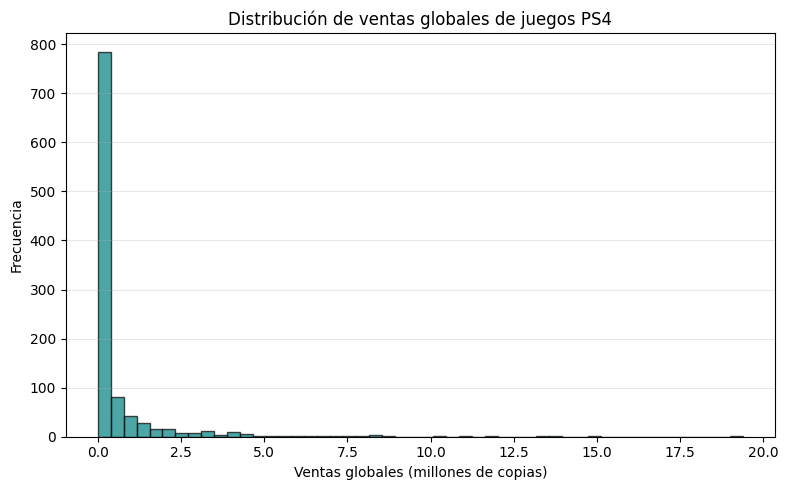

In [ ]:
# Histograma de ventas Globales

# Columnas del CSV:
# Game, Year, Genre, Publisher, North America, Europe, Japan, Rest of World, Global


import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['Global'], bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.xlabel('Ventas globales (millones de copias)')
plt.ylabel('Frecuencia')
plt.title('Distribución de ventas globales de juegos PS4')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('histograma_ps4_global.png', dpi=300, bbox_inches='tight')
plt.show()

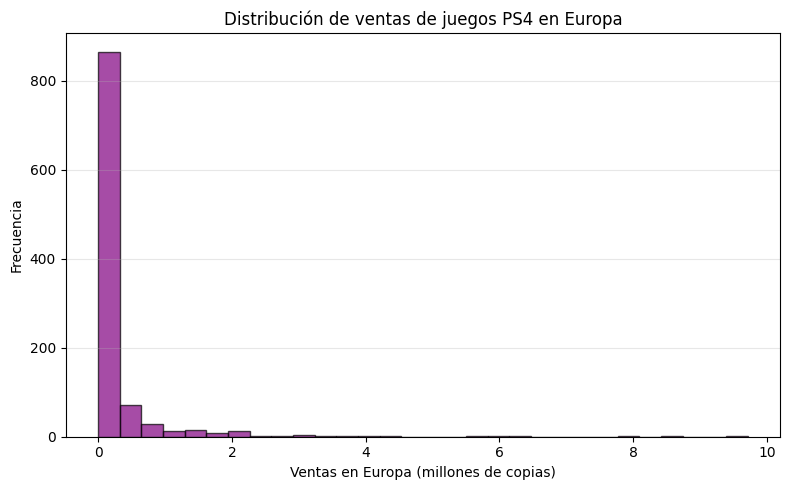

In [72]:
# Histograma de ventas en Europa


plt.figure(figsize=(8, 5))
plt.hist(df['Europe'], bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Ventas en Europa (millones de copias)')
plt.ylabel('Frecuencia')
plt.title('Distribución de ventas de juegos PS4 en Europa')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('histograma_ps4_europa.png', dpi=300, bbox_inches='tight')
plt.show()

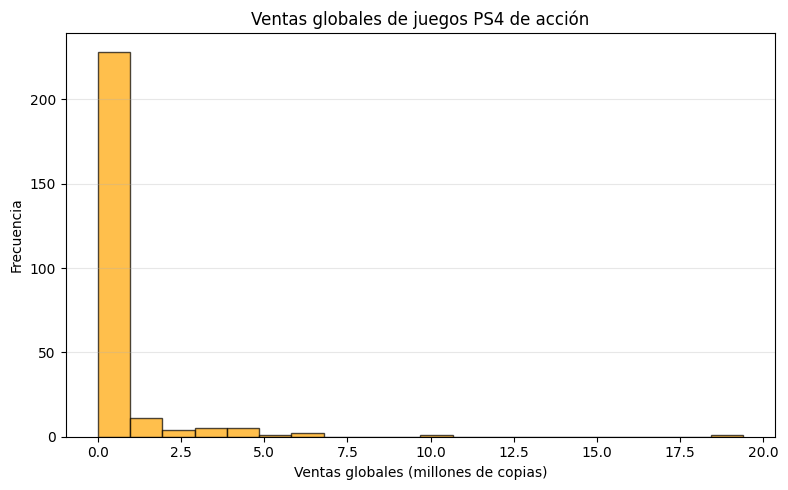

In [73]:
# Histograma por genero, en este caso, de acción
df_action = df[df['Genre'] == 'Action']

plt.figure(figsize=(8, 5))
plt.hist(df_action['Global'], bins=20, color='orange', edgecolor='black', alpha=0.7)
plt.xlabel('Ventas globales (millones de copias)')
plt.ylabel('Frecuencia')
plt.title('Ventas globales de juegos PS4 de acción')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('histograma_ps4_action.png', dpi=300, bbox_inches='tight')
plt.show()

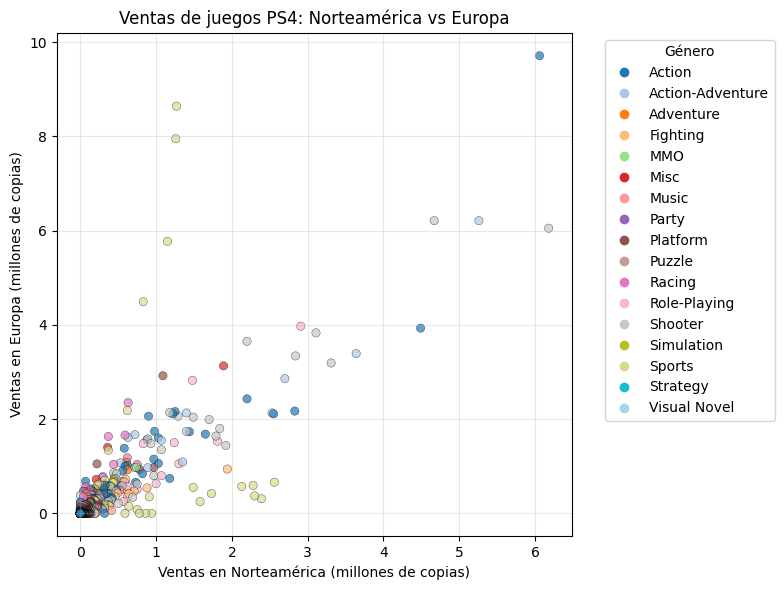

In [6]:
# Scatter básico: ventas NA vs Europa
# Va coloreado por género. Se ve como de relacionadas estan las ventas en 
# Norteamerica y en Europa y si hay géneros que venden mas en una región que en otra.


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Ps4.csv', encoding='latin1')


# Columnas: Game, Year, Genre, Publisher, North America, Europe, Japan, Rest of World, Global

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df['North America'],
    df['Europe'],
    c=pd.Categorical(df['Genre']).codes,
    cmap='tab20',
    alpha=0.7,
    edgecolor='black',
    linewidth=0.3)

plt.xlabel('Ventas en Norteamérica (millones de copias)')
plt.ylabel('Ventas en Europa (millones de copias)')
plt.title('Ventas de juegos PS4: Norteamérica vs Europa')

plt.grid(alpha=0.3)

handles = []
labels = []
for genre, code in zip(df['Genre'].astype('category').cat.categories,
        range(len(df['Genre'].astype('category').cat.categories))):
    handles.append(plt.Line2D([], [], marker="o", linestyle="", 
        color=plt.cm.tab20(code / max(1, len(df['Genre'].astype('category').cat.categories)-1))))
    labels.append(genre)
plt.legend(handles, labels, title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('scatter_ps4_naeu.png', dpi=300, bbox_inches='tight')
plt.show()

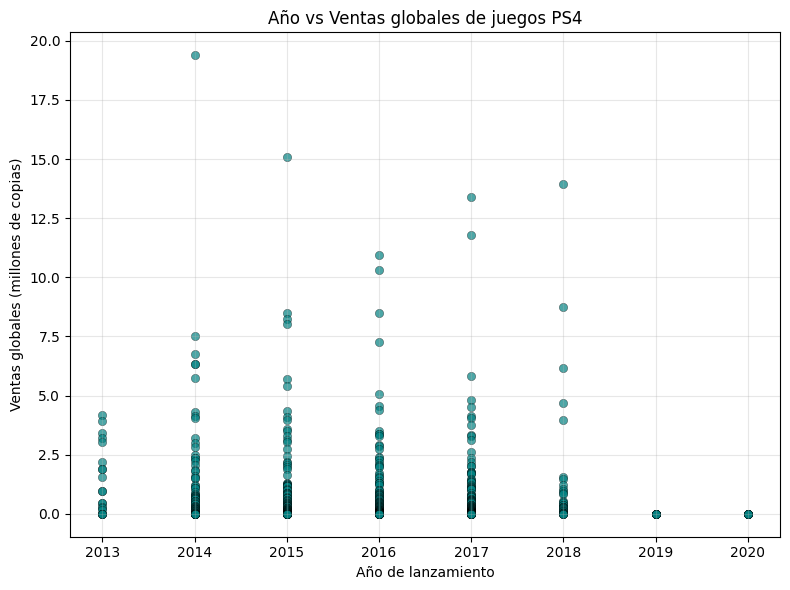

In [ ]:
# otro scatterplot pero con año de lanzamiento vs ventas globales.
# para ver si los juegos más nuevos venden mas o menos que los antiguos.


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Ps4.csv', encoding='latin1')


df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

plt.figure(figsize=(8, 6))

plt.scatter(
    df['Year'],
    df['Global'],
    alpha=0.7,
    edgecolor='black',
    linewidth=0.3,
    color='teal')

plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas globales (millones de copias)')
plt.title('Año vs Ventas globales de juegos PS4')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

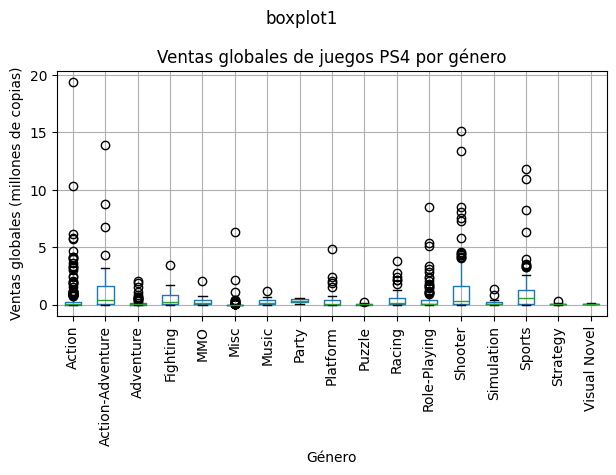

In [7]:
# boxplot loco de ventas globales por género.
# con esto se ve qué generos venden mas (mediana mas alta) , dispersión y posibles outliers.
# lo que veo: action y shooter, tienen medianas de ventas mas altas, asique se venden mas y 
# presentan mas dispersión y varios outliers por arriba, asique hay superventas.
# pero puzzle o miscelanea se venden menos.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Ps4.csv', encoding='latin1')

plt.figure(figsize=(10, 6))
df.boxplot(column='Global', by='Genre', rot=90)

plt.xlabel('Género')
plt.ylabel('Ventas globales (millones de copias)')
plt.title('Ventas globales de juegos PS4 por género')
plt.suptitle('boxplot1')
plt.tight_layout()
plt.savefig('', dpi=300, bbox_inches='tight')
plt.show()

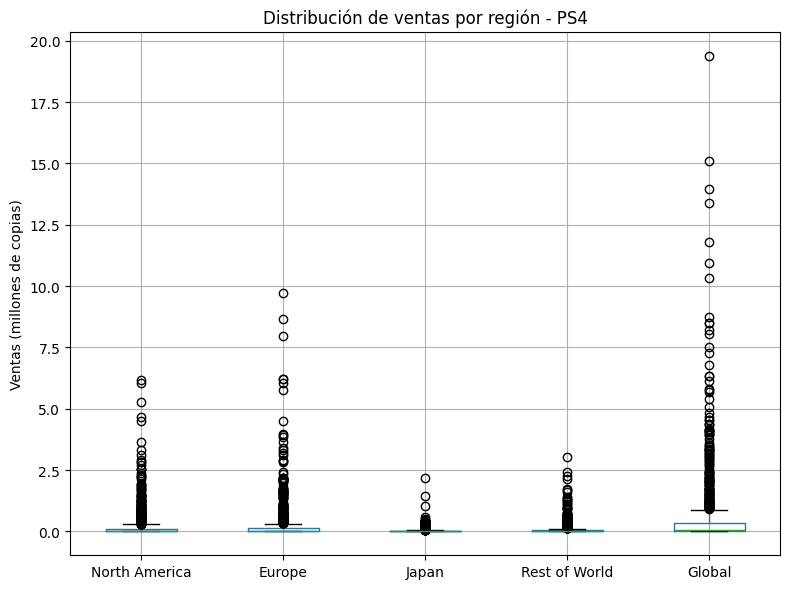

In [77]:
# boxplot 2, de ventas por region, pero todas a la vez
# aquí se comparan cómo se distribuyen las ventas entre regiones y globalmente.
# Na y Europa tienen medianas de ventas superiores al resto y ademas tienen mas variedad de títulos.
# Japón y el resto del mundo muestran medianas y rangos menores con ventas menores.
# los que tienen varios outliers por encima de los bigotes en na europa y ventas globales,
# tienen títulos superventas.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Ps4.csv', encoding='latin1')

columnas_regiones = ['North America', 'Europe', 'Japan', 'Rest of World', 'Global']

plt.figure(figsize=(8, 6))
df.boxplot(column=columnas_regiones)

plt.ylabel('Ventas (millones de copias)')
plt.title('Distribución de ventas por región - PS4')
plt.tight_layout()
plt.savefig('boxplot_ps4_regiones.png', dpi=300, bbox_inches='tight')
plt.show()

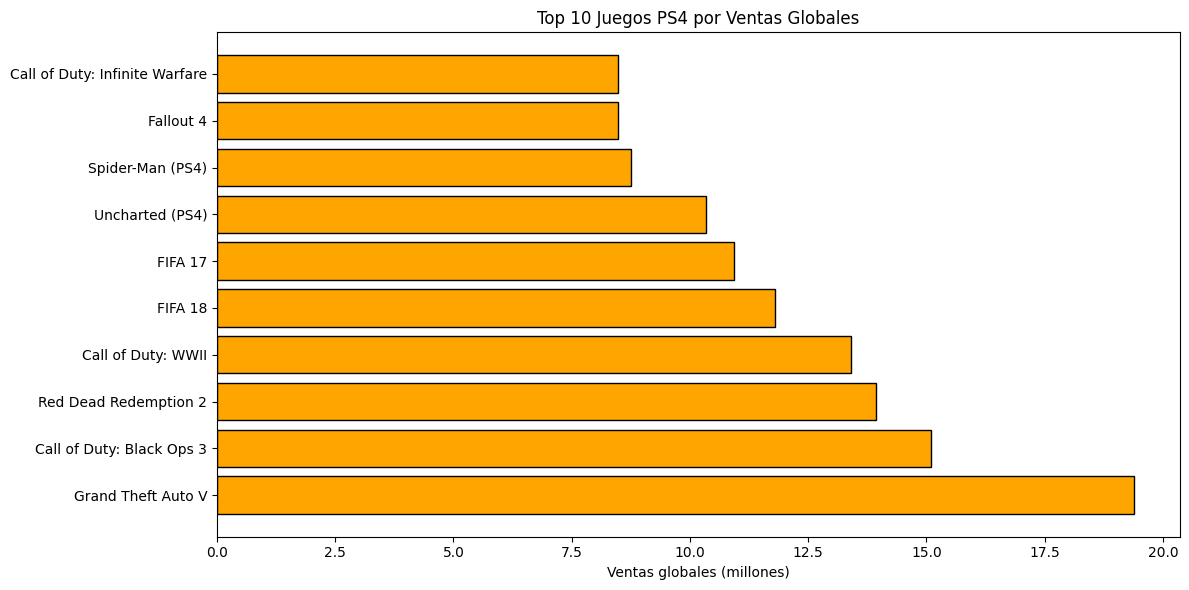

In [78]:
import matplotlib.pyplot as plt

top10 = df.nlargest(10, 'Global')[['Game', 'Global']].sort_values('Global')  # Orden ascendente para barras

plt.figure(figsize=(12, 6))
plt.barh(range(len(top10)), top10['Global'], color='orange', edgecolor='black')
plt.yticks(range(len(top10)), top10['Game'], fontsize=10)
plt.xlabel('Ventas globales (millones)')
plt.title('Top 10 Juegos PS4 por Ventas Globales')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_barras_ps4.png', dpi=300, bbox_inches='tight')
plt.show()

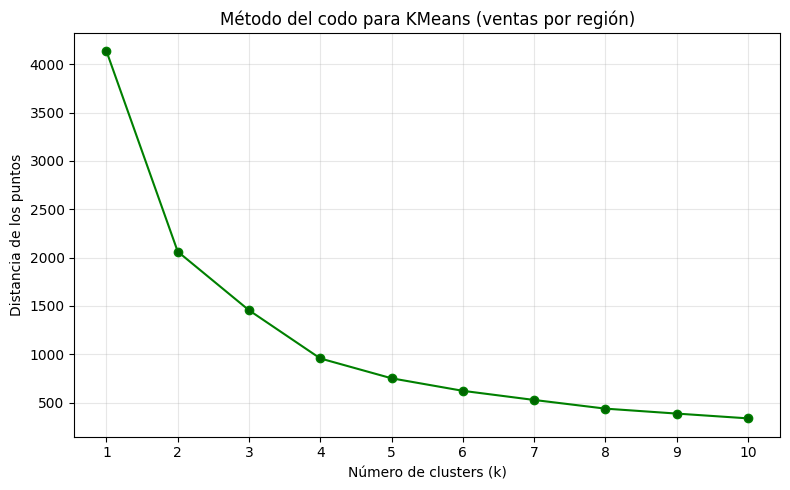

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#  Meto los datos
cols_regiones = ['North America', 'Europe', 'Japan', 'Rest of World']
X = df[cols_regiones]

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Codo
inertias = []
ks = range(1, 11) 

for k in ks:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_) 

# Este es el grafico
plt.figure(figsize=(8, 5))
plt.plot(ks, inertias, marker='o', color='green', markerfacecolor='darkgreen')
plt.xticks(ks)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Distancia de los puntos')
plt.title('Método del codo para KMeans (ventas por región)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_codo_ps4_regiones.png', dpi=300, bbox_inches='tight')
plt.show()

In [80]:
clusters = KMeans(3, n_init=10).fit_predict(X_scaled)
df['Cluster'] = clusters
df.head()

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global,Cluster
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39,1
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09,1
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94,1
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40,1
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80,1


In [ ]:
import pandas as pd

# Asegurar que Year es numérico
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Creamos una columna categórica derivada simple que va a ser, década
df["decade"] = (df["Year"] // 10) * 10  # 2014 -> 2010, 2018 -> 2010, etc.

# Paso variables categóricas a dummies (Genre y Publisher)
# aunque Publisher tiene nulos pero los lleno con 'Unknown'
df["Publisher"] = df["Publisher"].fillna("Unknown")

df_dum = pd.get_dummies(df, columns=["Genre", "Publisher"], drop_first=True)

# le doy a X con numéricas + nueva categórica decade, por la decada
# que he dicho antes.
X = df_dum[[
    "Year",
    "North America",
    "Europe",
    "Japan",
    "Rest of World",
    "decade"
]].copy()

# le sumo las dummies de Genre y Publisher
# la c es una variable temporal que verifica que el nombre es genre.
# concat en pandas combina varios objetos 
# y el axis es la fila en la que estas 
genre_cols = [c for c in df_dum.columns if c.startswith("Genre_")]
publisher_cols = [c for c in df_dum.columns if c.startswith("Publisher_")]

X = pd.concat([X, df_dum[genre_cols + publisher_cols]], axis=1)

# Escalo manual (media 0, varianza 1)
X_scaled = (X - X.mean()) / X.std()

# le pongo un print para que devuelva algo en pantalla 
print(X_scaled.head())
print("Shape:", X_scaled.shape)

       Year  North America     Europe     Japan  Rest of World    decade  \
0 -1.514264      10.391635  12.045052  5.227471      11.751673 -0.098894   
1 -0.744062      10.604600   7.385549  3.473793       9.426187 -0.098894   
2  1.566544       8.971864   7.589244  1.627816       8.704484 -0.098894   
3  0.796342       7.924783   7.589244  3.381494       8.143159 -0.098894   
4  0.796342       1.890756  10.682848  1.074023       6.579470 -0.098894   

   Genre_Action-Adventure  Genre_Adventure  Genre_Fighting  Genre_MMO  ...  \
0               -0.200506        -0.321593       -0.187086  -0.088259  ...   
1               -0.200506        -0.321593       -0.187086  -0.088259  ...   
2                4.982566        -0.321593       -0.187086  -0.088259  ...   
3               -0.200506        -0.321593       -0.187086  -0.088259  ...   
4               -0.200506        -0.321593       -0.187086  -0.088259  ...   

   Publisher_Ubisoft  Publisher_Unknown  Publisher_Versus Evil  \
0       

In [82]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# year es numerico y luego lo quito para no liarme 
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df_p4 = df.dropna(subset=["Year"]).copy()

# Me quedo con las features para PCA, que son year y ventasporregion
X = df_p4[["Year", "North America", "Europe", "Japan", "Rest of World"]].copy()

# Meto género en dummies 
X = pd.get_dummies(X.join(df_p4["Genre"]), columns=["Genre"], drop_first=False)

# Guardo las etiquetas del juego para visualizar despues
game_labels = df_p4["Game"].copy()
genre_labels = df_p4["Genre"].copy()

# Escalo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por cada componente:",
      pca.explained_variance_ratio_)
print("Varianza explicada acumulada:",
      pca.explained_variance_ratio_.cumsum())

# DataFrame PCA + etiquetas
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Game"] = game_labels.values
df_pca["Genre"] = genre_labels.values

df_pca.head()

Varianza explicada por cada componente: [0.1441534  0.05925621]
Varianza explicada acumulada: [0.1441534  0.20340962]


,PC1,PC2,Game,Genre
0,17.834496,1.436530,Grand Theft Auto V,Action
1,14.634284,-0.029259,Call of Duty: Black Ops 3,Shooter
2,12.782431,0.266107,Red Dead Redemption 2,Action-Adventure
3,12.647784,0.652196,Call of Duty: WWII,Shooter
4,9.586490,-1.149635,FIFA 18,Sports


Varianza explicada por cada componente: [0.1441534  0.05925621]
Varianza explicada acumulada: [0.1441534  0.20340962]


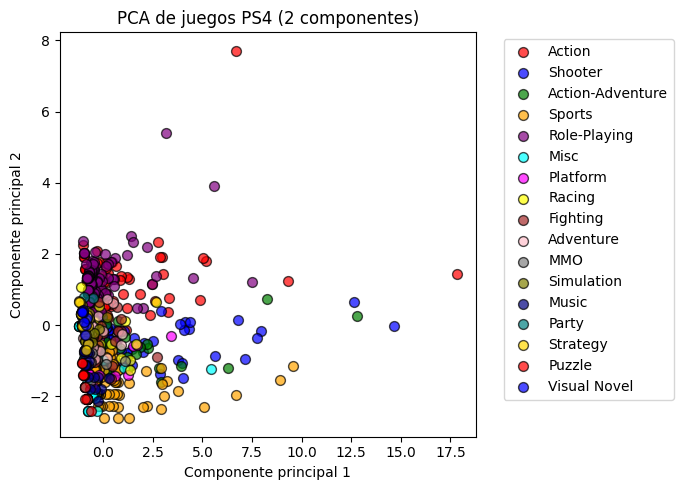

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Year es numérico y quitar nulos en Year
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df_p4 = df.dropna(subset=["Year"]).copy()

# features para PCA son, year, ventas por region, los dummies de genre
X = df_p4[["Year", "North America", "Europe", "Japan", "Rest of World"]].copy()
X = pd.get_dummies(X.join(df_p4["Genre"]), columns=["Genre"], drop_first=False)

# Etiquetas
game_labels = df_p4["Game"].copy()
genre_labels = df_p4["Genre"].copy()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por cada componente:",
      pca.explained_variance_ratio_)
print("Varianza explicada acumulada:",
      pca.explained_variance_ratio_.cumsum())

# DataFrame con PC1, PC2 y etiquetas
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Game"] = game_labels.values
df_pca["Genre"] = genre_labels.values


# Scatter PC1 vs PC2 con lista de colores manual
plt.figure(figsize=(7, 5))

genres = df_pca["Genre"].unique()
n_genres = len(genres)

# Lista de colores definida a mano
colors_list = [
    "red", "blue", "green", "orange", "purple",
    "cyan", "magenta", "yellow", "brown", "pink",
    "gray", "olive", "navy", "teal", "gold"]

for i, genre in enumerate(genres):
    subset = df_pca[df_pca["Genre"] == genre]
    color = colors_list[i % len(colors_list)]
    plt.scatter(
    subset["PC1"],
    subset["PC2"],
    c=color,
    label=genre,
    alpha=0.7,
    edgecolors='k',
     s=50)

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('PCA de juegos PS4 (2 componentes)')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Tipos de variables del DataFrame PS4

```text
Column         Non-Null Count  Dtype  
0   Game           1034 non-null   str    
1   Year           825 non-null    float64
2   Genre          1034 non-null   str    
3   Publisher      825 non-null    str    
4   North America  1034 non-null   float64
5   Europe         1034 non-null   float64
6   Japan          1034 non-null   float64
7   Rest of World  1034 non-null   float64
8   Global         1034 non-null   float64
```

### Tabla resumen de variables

| Columna        | Tipo en df.info | Tipo estadístico               | Comentario de uso principal                                    |
|----------------|-----------------|--------------------------------|-----------------------------------------------------------------|
| Game           | str             | Categórica nominal (ID)       | Identificador del juego; útil para etiquetas y filtros.        |
| Year           | float64         | Numérica (tiempo, discreta)   | Año de lanzamiento; para tendencias y como feature numérico.   |
| Genre          | str             | Categórica nominal            | Género del juego; para agrupar, boxplots y dummies en modelos. |
| Publisher      | str             | Categórica nominal            | Editor; muchas categorías y algunos nulos.                     |
| North America  | float64         | Numérica continua             | Ventas regionales (NA); feature clave.                         |
| Europe         | float64         | Numérica continua             | Ventas regionales (Europa); feature clave.                     |
| Japan          | float64         | Numérica continua             | Ventas regionales (Japón); feature clave.                      |
| Rest of World  | float64         | Numérica continua             | Ventas regionales (Resto del mundo); feature clave.            |
| Global         | float64         | Numérica continua (target)    | Ventas totales; objetivo natural para regresión.               |